In [1]:
import numpy as np
from scipy import *
from sympy import *
import qutip as qt
init_printing()
import matplotlib.pyplot as plt

In [2]:
HCE = np.load("HCE.npy")

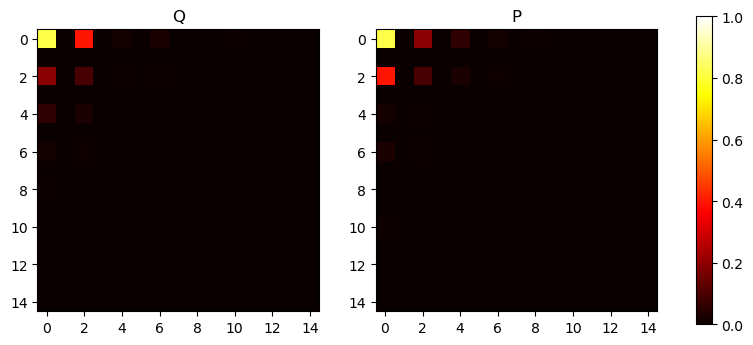

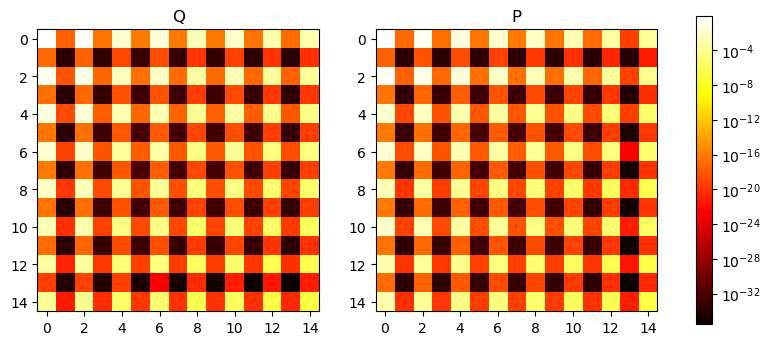

In [4]:
HCE_Q=qt.Qobj(HCE)
HCE_Q.dims=[[2,2,15,15], [2,2,15,15]]
M1=HCE_Q.ptrace([2])
M2=HCE_Q.ptrace([3])
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
im1 = ax1.imshow(np.abs(M1.full()), cmap='hot', vmin=0, vmax=1)
ax1.set_title('Q')
ax1.set_xticks(np.arange(0,15,2))
ax1.set_yticks(np.arange(0,15,2))
im2 = ax2.imshow(np.abs(M2.full()), cmap='hot', vmin=0, vmax=1)
ax2.set_title('P')
ax2.set_xticks(np.arange(0,15,2))
ax2.set_yticks(np.arange(0,15,2))
cbar = fig.colorbar(im1, ax = [ax1, ax2], orientation = 'vertical')
plt.show()
from matplotlib.colors import LogNorm
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
im1 = ax1.imshow(np.abs(M1.full()), cmap='hot', norm=LogNorm())
ax1.set_title('Q')
ax1.set_xticks(np.arange(0,15,2))
ax1.set_yticks(np.arange(0,15,2))
im2 = ax2.imshow(np.abs(M2.full()), cmap='hot', norm=LogNorm())
ax2.set_title('P')
ax2.set_xticks(np.arange(0,15,2))
ax2.set_yticks(np.arange(0,15,2))
cbar = fig.colorbar(im1, ax = [ax1, ax2], orientation = 'vertical')
plt.show()

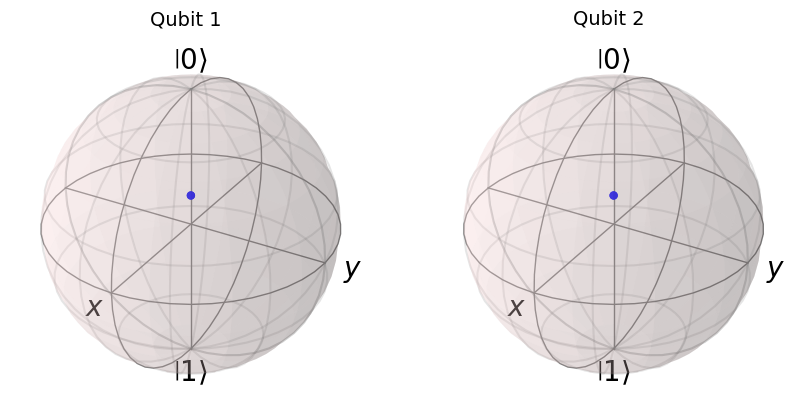

In [6]:
import graphics as gr
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1,2,1,projection='3d')
ax2 = fig.add_subplot(1,2,2,projection='3d')

b1=qt.Bloch(fig=fig, axes=ax1)
b2=qt.Bloch(fig=fig, axes=ax2)
b1.add_points(gr.rho2bloch(HCE_Q.ptrace([0])))
b2.add_points(gr.rho2bloch(HCE_Q.ptrace([1])))
b1.render()
b2.render()
ax1.set_title("Qubit 1", fontsize = 14, pad = 20)
ax2.set_title("Qubit 2", fontsize = 14, pad = 20)
plt.show()

c:\Users\nicol\.conda\envs\tfg_fis\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 0, '$\\rho$')

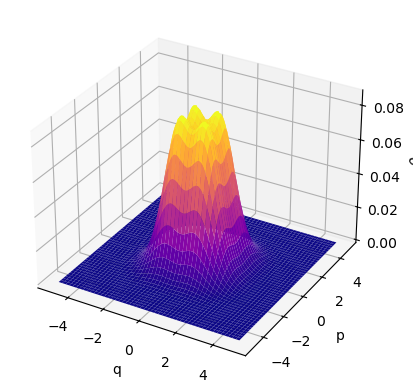

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(q_grid, p_grid, prob, cmap='plasma')
ax.set_xlabel("q")
ax.set_ylabel("p")
ax.set_zlabel(r"$\rho$")

In [2]:
N_c=5 #Number of classical states for each oscillator
S=0.5 #Spin
N_Q=int(2*S+1)

I_c = qt.qeye(N_c)
I_Q = qt.qeye(N_Q)
a=qt.destroy(N_c)
a_q = qt.tensor(a, I_c)
a_d_q = a_q.dag()
a_p = qt.tensor(I_c, a)
a_d_p = a_p.dag()

Q = 1/np.sqrt(2)*(a_q+a_d_q)
P = 1/np.sqrt(2)*(a_p+a_d_p)
Pi_Q = -1j/np.sqrt(2)*(a_q-a_d_q)
Pi_P = -1j/np.sqrt(2)*(a_p-a_d_p)

cQ = Q.cosm()
sQ = Q.sinm()
zero = np.zeros(N_c**2)

Id_dim = qt.qeye(N_c**2)
Id_dim.dims = [[N_c, N_c], [N_c, N_c]]
E1 =(Id_dim+Q*Q).inv()
E2 = E1 + Id_dim+ 0.1*Q*Q
print(E1.dims, cQ.dims, Q.dims, Id_dim.dims)

[[5, 5], [5, 5]] [[5, 5], [5, 5]] [[5, 5], [5, 5]] [[5, 5], [5, 5]]


In [ ]:
H_QP = np.zeros((4, 4, N_c**2, N_c**2), dtype=complex)

H_QP[0,0] = np.array((E1*(cQ+Id_dim)+E2*(Id_dim-cQ)).full())
H_QP[3,3] = np.array((E1*(Id_dim-cQ)+E2*(Id_dim+cQ)).full())
H_QP[1,1] = H_QP[2,2] = np.array((E1+E2).full())
H_QP[0,3] = H_QP[1,2] = H_QP[2,1] = H_QP[3,0] = zero
H_QP[0,1] = H_QP[0,2] = H_QP[1,0] = H_QP[2,0] = H_QP[3,1] = H_QP[3,2] = H_QP[1,3] = H_QP[2,3] = 0.5 * np.array(((E1-E2)*sQ).full())

dim_total = N_c**2 * N_Q**2
H_QP_2D = H_QP.transpose(0, 2, 1, 3).reshape((dim_total, dim_total))

H = H_QP_2D + qt.tensor(I_Q, I_Q, P*Pi_Q - Q*Pi_P).full()
H = (H + H.conj().T) / 2.0

np.save("hamiltonian_5_2.npy", H)

C:\Users\nicol\AppData\Local\Temp\ipykernel_20084\3264355839.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  H_QP[0,0] = np.matrix((E1*(cQ+Id_dim)+E2*(Id_dim-cQ)+0.5*P*P+0.5*Q*Q).full())
C:\Users\nicol\AppData\Local\Temp\ipykernel_20084\3264355839.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  H_QP[3,3] = np.matrix((E1*(Id_dim-cQ)+E2*(Id_dim+cQ)+0.5*P*P+0.5*Q*Q).full())
C:\Users\nicol\AppData\Local\Temp\ipykernel_20084\3264355839.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  H_QP[1,1] = H_QP[2,2]= np.matrix((E1+E2+0.5*P*P+0.5*Q*Q).full())
C:\Users\nicol\AppData\Local\Temp\ipykernel_20084\3264355839.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  H_QP[0,1] = H_QP[0,2] = H_QP[1,0] =H_QP[2,0] = H_QP[3,1]=H_QP[3,2] =H_QP[1,3] = H_QP[2,3] = 0.5*np.matrix(((E1-E2)*sQ).full())


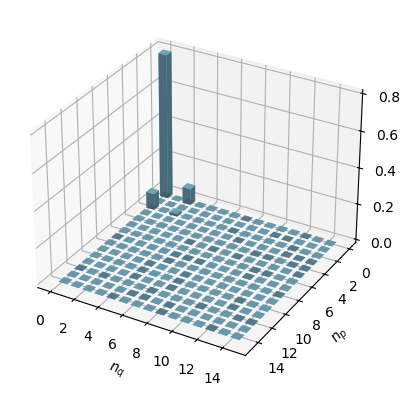

In [17]:
HCE_classical_diag = HCE_Q.ptrace([2,3]).diag()
HCE_classical_diag /= np.sum(HCE_classical_diag)
mat = HCE_classical_diag.reshape((N_c, N_c))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.invert_yaxis()
ax.set_xticks(np.arange(0,N_c,2))
ax.set_yticks(np.arange(0,N_c,2))
ax.set_xlabel(r"$n_q$")
ax.set_ylabel(r"$n_p$")

nqgrid, npgrid = np.meshgrid(np.arange(N_c),np.arange(N_c),indexing='ij')
nqgrid_flat = nqgrid.ravel()
npgrid_flat = npgrid.ravel()
z = np.zeros_like(nqgrid_flat)
Delta_z = mat.ravel()

dx=dy=0.7

ax.bar3d(nqgrid_flat, npgrid_flat, z, dx, dy, Delta_z, color='skyblue', alpha = 0.8)
plt.show()


In [16]:
a= qt.destroy(N_c)
a_d=a.dag()
Q = 1/np.sqrt(2)*(a+a_d)
Q2op=Q*Q

print((qt.Qobj(HCE_Q.ptrace(2).full())*Q2op).tr())
print((qt.Qobj(HCE_Koopman_Q.ptrace(2).full())*Q2op).tr())
import h5py
with h5py.File("results/h_0_1_10_100_different.h5", "r") as f:
    print(f["classical_q"][:])

(1.131251083549085+0j)
(494.65910855466507+0j)
[[1.23870525+0.00000000e+00j]
 [1.23870525+3.57447904e-18j]
 [1.23870525-3.24447500e-17j]
 [1.23870525+3.96546945e-17j]
 [1.23870525-1.00424226e-17j]
 [1.23870525+1.74014449e-17j]
 [1.23870525-6.93889390e-18j]
 [1.23870525+2.42861287e-17j]
 [1.23870525+2.25514052e-17j]
 [1.23870525+4.51028104e-17j]
 [1.23870525-1.73472348e-17j]
 [1.23870525-6.59194921e-17j]
 [1.23870525-5.20417043e-17j]
 [1.23870525+1.73472348e-17j]
 [1.23870525+6.50521303e-17j]
 [1.23870525+4.16333634e-17j]
 [1.23870525+6.33174069e-17j]
 [1.23870525-2.60208521e-18j]
 [1.23870525+1.00613962e-16j]
 [1.23870525-3.51281504e-17j]
 [1.23870525+3.12250226e-17j]
 [1.23870525+1.38777878e-17j]
 [1.23870525-3.46944695e-18j]
 [1.23870525+2.08166817e-17j]
 [1.23870525+1.04083409e-17j]
 [1.23870525+1.73472348e-17j]
 [1.23870525-3.46944695e-17j]
 [1.23870525+6.93889390e-18j]
 [1.23870525-2.77555756e-17j]
 [1.23870525+3.46944695e-17j]
 [1.23870525-1.04083409e-17j]
 [1.23870525-6.59194921

In [2]:
qt.about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.2.3
Numpy Version:      2.4.2
Scipy Version:      1.16.3
Cython Version:     None
Matplotlib Version: 3.10.8
Python Version:     3.14.2
Number of CPUs:     8
BLAS Info:          mkl-sdl
INTEL MKL Ext:      None
Platform Info:      Windows (AMD64)
Installation path:  c:\Users\nicol\.conda\envs\tfg_fis\Lib\site-packages\qutip

Installed QuTiP family packages
-------------------------------

No QuTiP family packages installed.

Please cit